### Load all simulation complexes

Load all simulation complexes.


In [4]:
import os
from tqdm.notebook import tqdm
import MDAnalysis as mda
import numpy as np
import matplotlib.pyplot as plt

ligand_name = "PDL"
simdir = "1lml_pdl_complex_scaled8"
data_dirname = "sys_prod"
data_dir = os.path.join(simdir, data_dirname)
xtc_file = os.path.join(data_dir,  "prod_" + simdir + "_compact_compact.xtc")
top_file = os.path.join(data_dir, "prod_" + simdir + ".tpr")

Prepare protlig tpr selections for each complex (unless it already exists from old PP)

Now, prepare MDAnalysis universes for each complex

In [5]:
complex = mda.Universe(top_file, xtc_file)

### Calculate all RMSD values and load in a dataframe

  0%|          | 0/1001 [00:00<?, ?it/s]

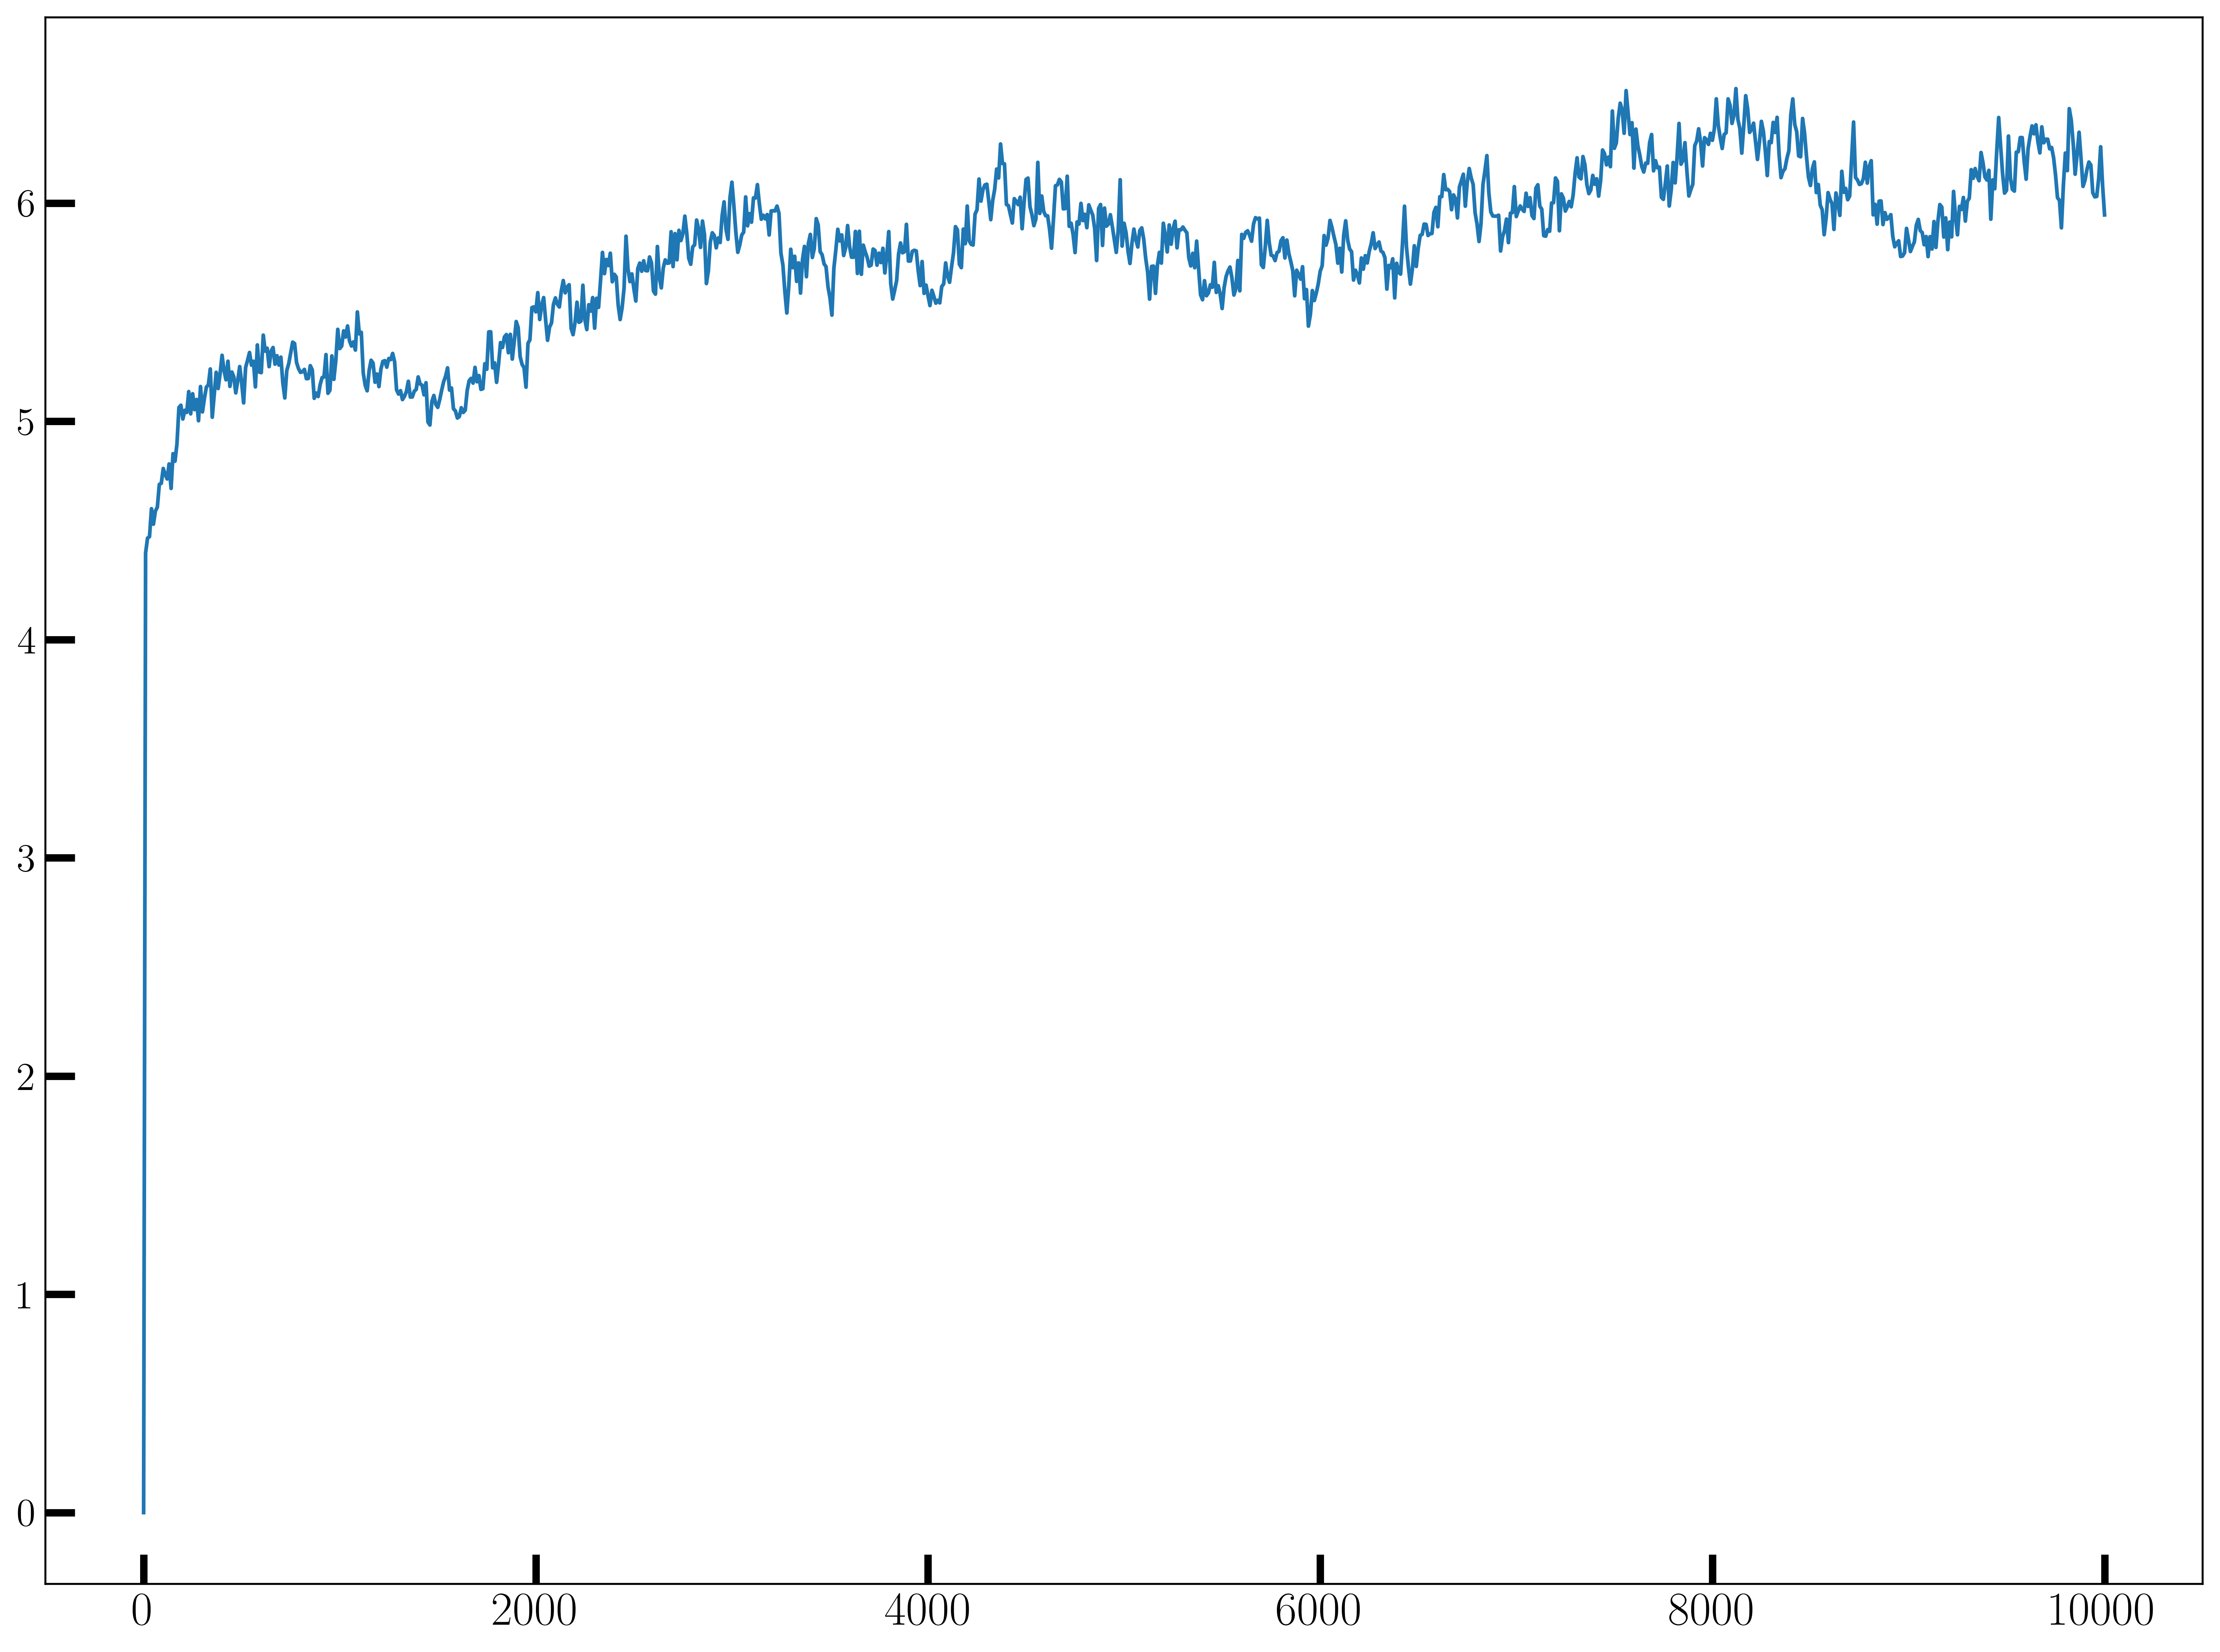

In [6]:
from MDAnalysis.analysis import rms
R = rms.RMSD(complex, complex, select='backbone', ref_frame=0)
R.run(verbose=True)
times = R.results.rmsd[:, 1]
rmsd = R.results.rmsd[:, 2]
plt.plot(times, rmsd)

In [8]:
# Put the rmsd data into a pandas dataframe
import pandas as pd
df = pd.DataFrame({'time': times, 'rmsd': rmsd})

### Calculate all RMSF and load in the previous pandas dataframe

<Axes: xlabel='resid'>

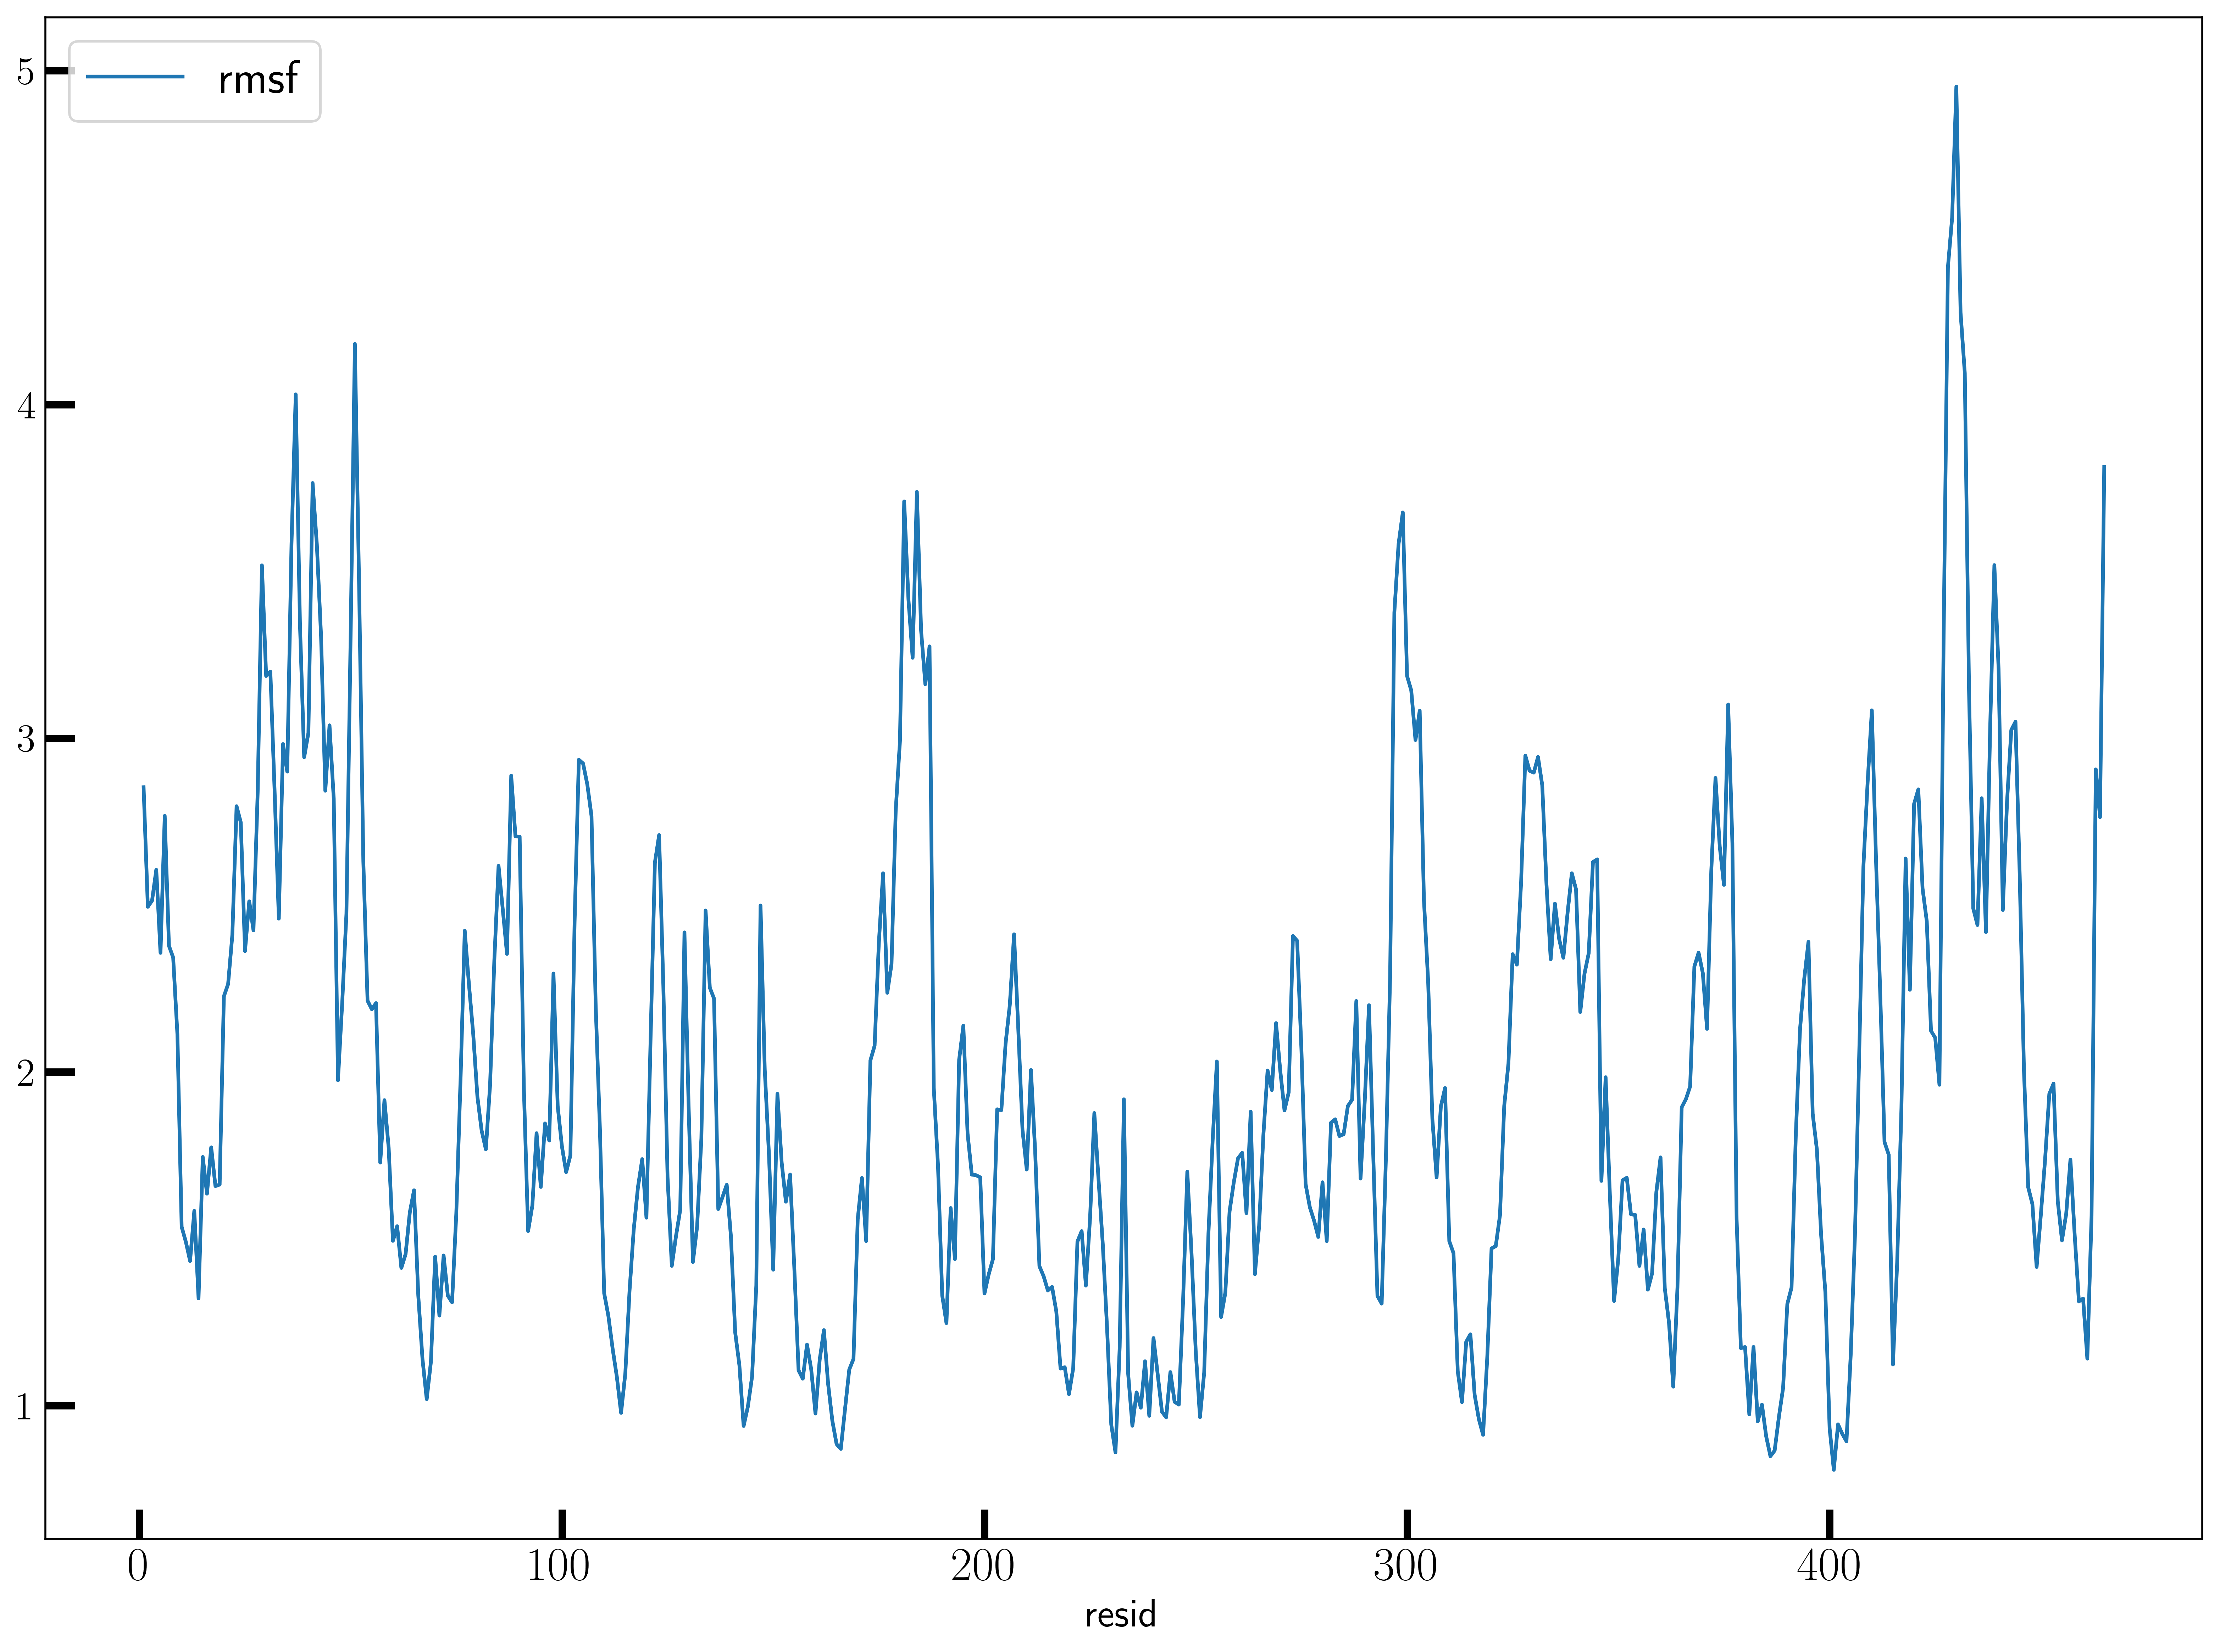

In [10]:
sel = complex.select_atoms('backbone and name CA')
R = rms.RMSF(sel).run(verbose=False)
resids = np.array(sel.resids)
rmsf = np.array(R.results.rmsf)

#Put these into the dataframe df. They may not be the same size as the other data, so pad them with NaNs
df['resid'] = np.nan
df['rmsf'] = np.nan
df.loc[:len(resids)-1, 'resid'] = resids
df.loc[:len(rmsf)-1, 'rmsf'] = rmsf
df.plot(x='resid', y='rmsf')


### Calculate all Radus of Gyration and load in the dataframe

In [60]:
from tqdm.notebook import tqdm
group = complex.select_atoms('protein')
times = []
rg = []
for ts in tqdm(complex.trajectory):
    times.append(ts.time)
    rg.append(group.radius_of_gyration())

  0%|          | 0/1001 [00:00<?, ?it/s]

In [62]:
df['time_rg'] = times
df['rg'] = rg # convert from Angstroms to nm
df

,time,rmsd,resid,rmsf,time_rg,rg
0,0.0,6.129725e-07,1.0,2.852616,0.0,23.038423
1,10.0,4.396733e+00,2.0,2.494242,10.0,24.603058
2,20.0,4.465314e+00,3.0,2.513035,20.0,24.259312
3,30.0,4.471830e+00,4.0,2.605419,30.0,24.218030
4,40.0,4.599914e+00,5.0,2.356390,40.0,24.152852
...,...,...,...,...,...,...
996,9960.0,6.030561e+00,NaN,NaN,9960.0,24.708921
997,9970.0,6.113088e+00,NaN,NaN,9970.0,24.723281
998,9980.0,6.258305e+00,NaN,NaN,9980.0,24.704144
999,9990.0,6.079740e+00,NaN,NaN,9990.0,24.747046


### Number of hydrogen bonds between protein and ligand

In [ ]:
from MDAnalysis.analysis.hydrogenbonds.hbond_analysis import HydrogenBondAnalysis as HBA
import numpy as np
import pandas as pd

# I need to know the name of the protein residues that participate

# Strictly select protein and ligand atoms. Note that there is water in these trajectories for some reason...
protein = complex.select_atoms("protein")
ligand = complex.select_atoms("resname PDL")

# Run HBA specifically for Protein (Donors) - Ligand (Acceptors)
hbs = HBA(universe=complex, donors_sel="protein", acceptors_sel="resname PDL")
hbs.run(verbose=True)

# Run HBA specifically for Ligand (Donors) - Protein (Acceptors)
hbs_rev = HBA(universe=complex, donors_sel="resname PDL", acceptors_sel="protein")
hbs_rev.run(verbose=True)

# Combine and identify protein residues
protein_residues = []
all_hbonds = np.vstack([hbs.results.hbonds, hbs_rev.results.hbonds])

for hb in all_hbonds:
    d_idx, a_idx = int(hb[1]), int(hb[3])
    # Identify which atom belongs to the protein
    if d_idx in protein.indices:
        res = complex.atoms[d_idx].residue
        protein_residues.append(f"{res.resname}{res.resid}")
    elif a_idx in protein.indices:
        res = complex.atoms[a_idx].residue
        protein_residues.append(f"{res.resname}{res.resid}")

print(f"Total H-bonds found: {len(all_hbonds)}")
set(protein_residues)

  0%|          | 0/1001 [00:00<?, ?it/s]

  0%|          | 0/1001 [00:00<?, ?it/s]

Total H-bonds found: 99


{'ALA149',
 'ALA229',
 'ARG366',
 'ASN150',
 'GLN365',
 'GLU369',
 'HIS165',
 'ILE151',
 'PRO248',
 'TRP127',
 'VAL159',
 'VAL162',
 'VAL163'}

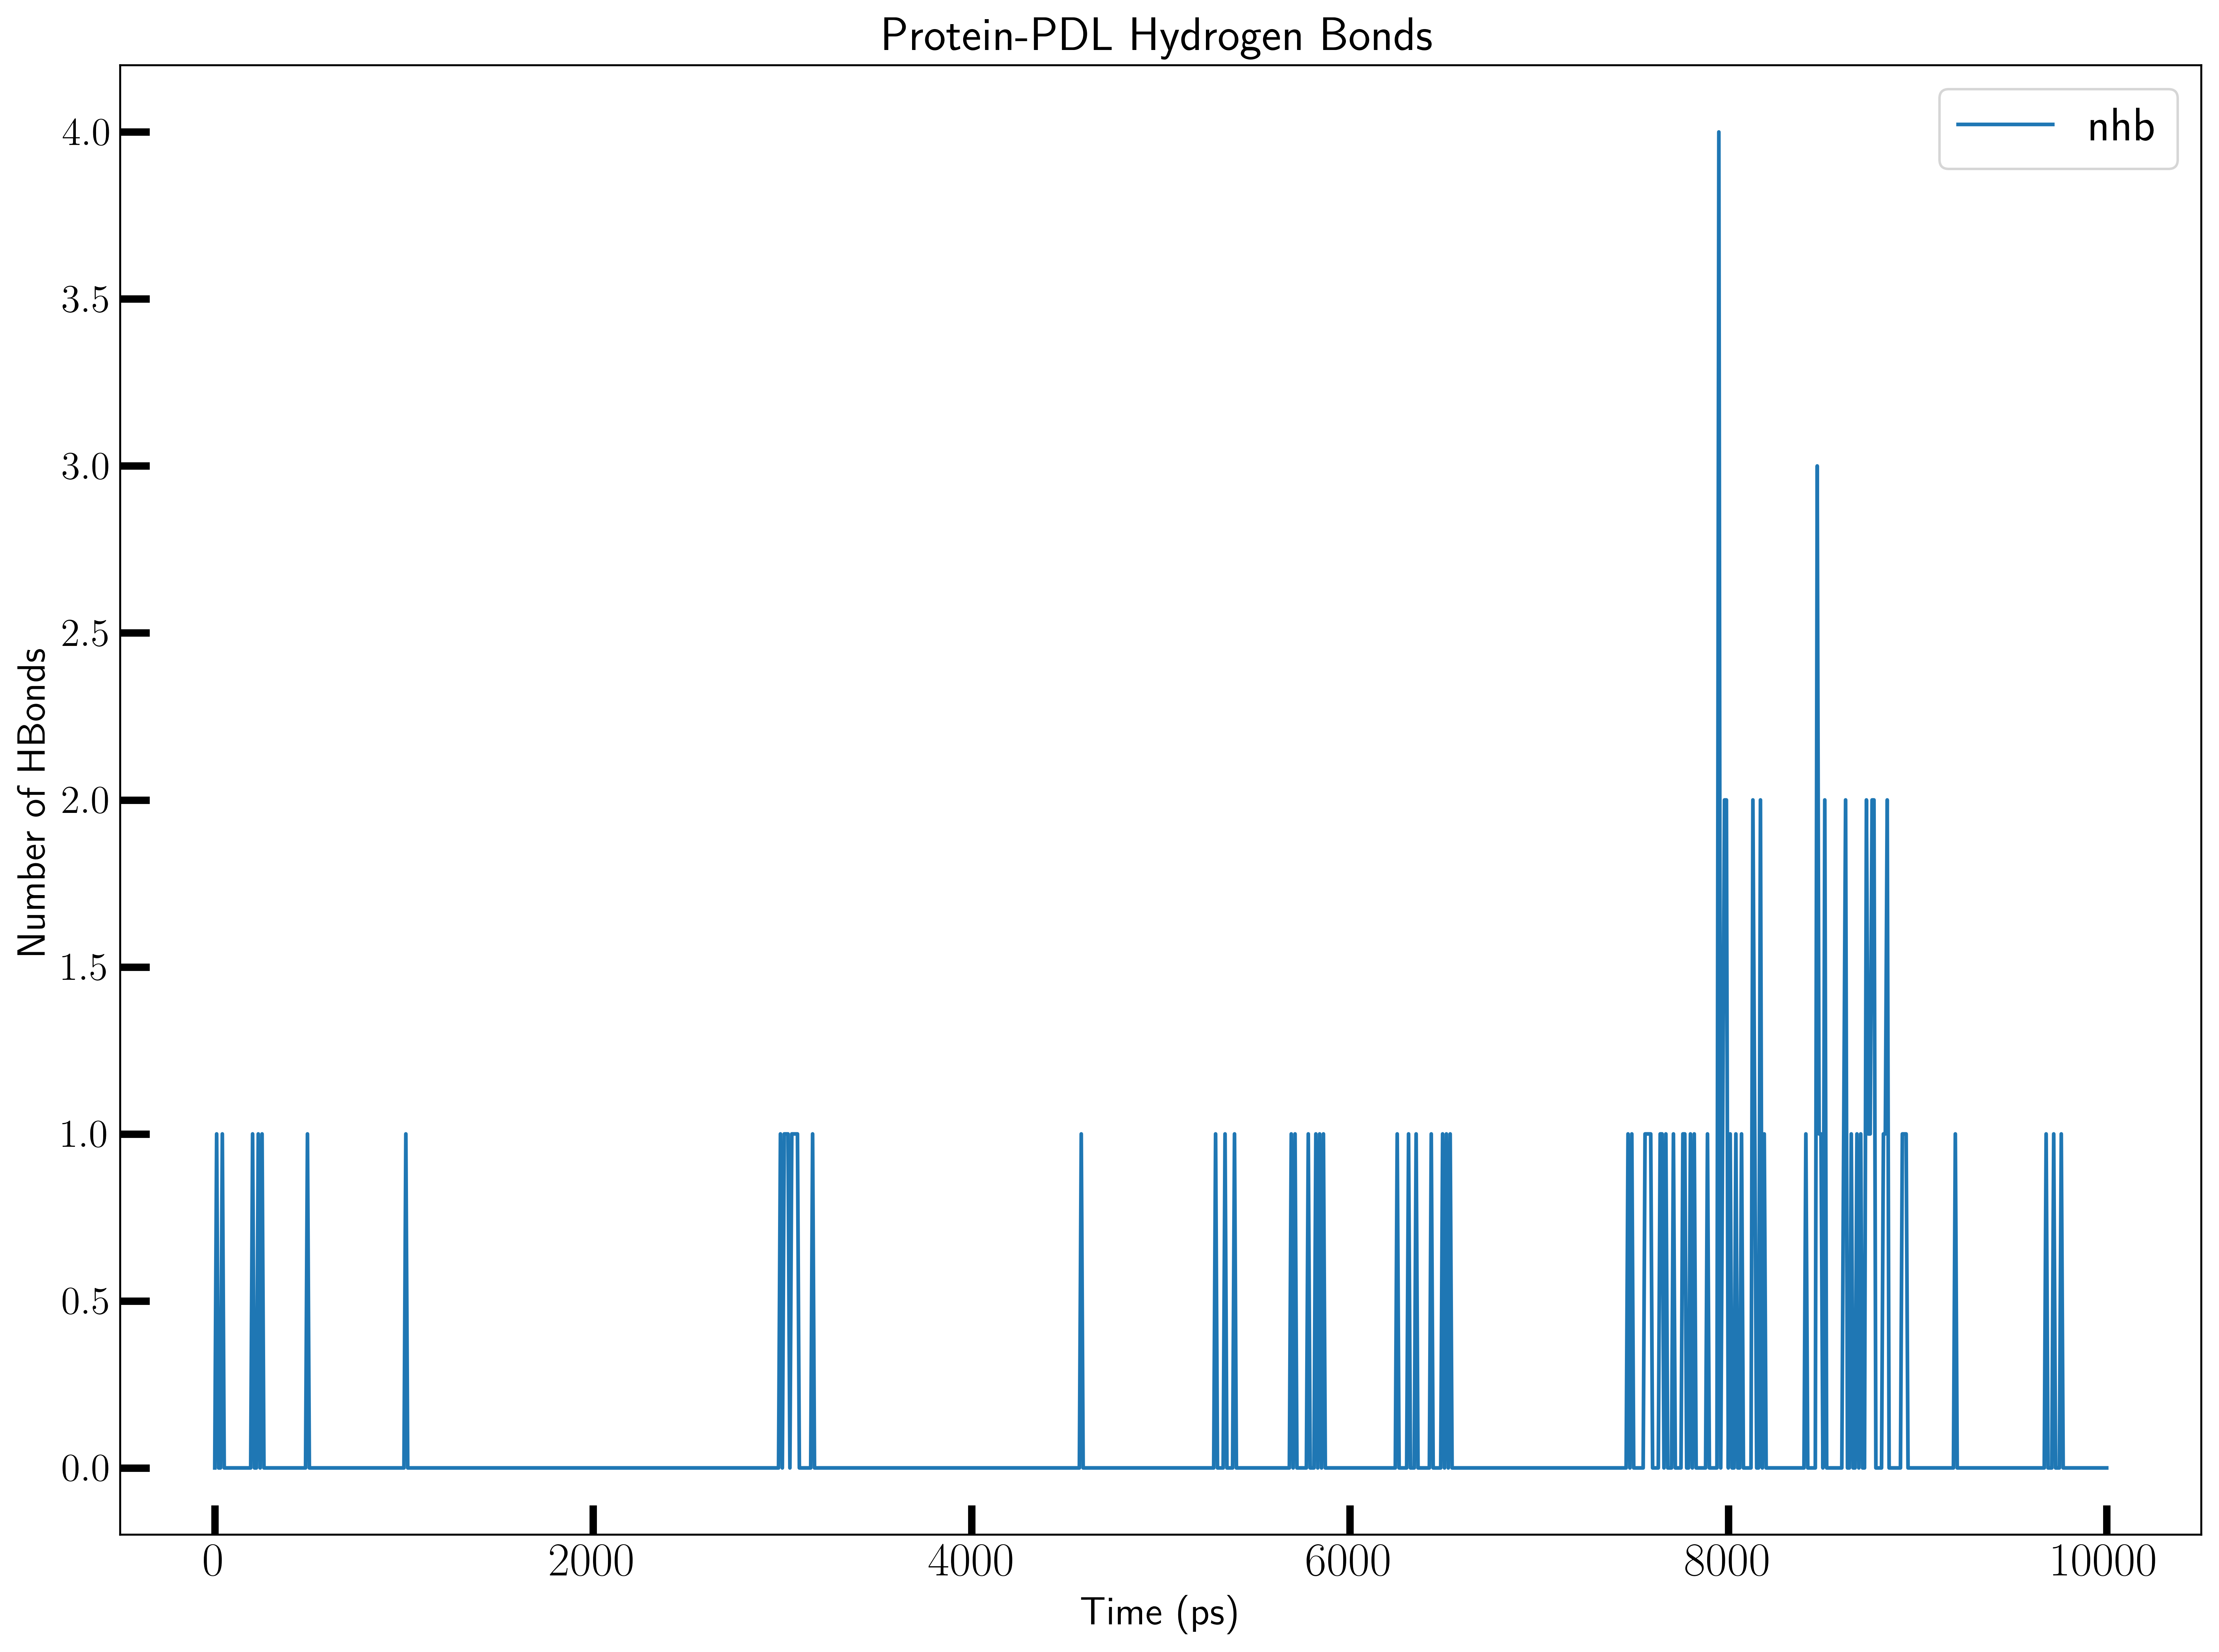

In [ ]:
# Calculate counts per frame for the combined set
times = hbs.times
if all_hbonds.size == 0:
    nhb = np.zeros_like(times, dtype=int)
else:
    frames = all_hbonds[:, 0].astype(int)
    nhb = np.bincount(frames, minlength=len(times))[:len(times)]

# Create DataFrame and Plot
nhb_df = pd.DataFrame({'Time': times, 'nhb': nhb})
nhb_df.set_index('Time', inplace=True)
nhb_df.plot()
plt.xlabel('Time (ps)')
plt.ylabel('Number of HBonds')
plt.title('Protein-PDL Hydrogen Bonds')
plt.show()

### Plot everything

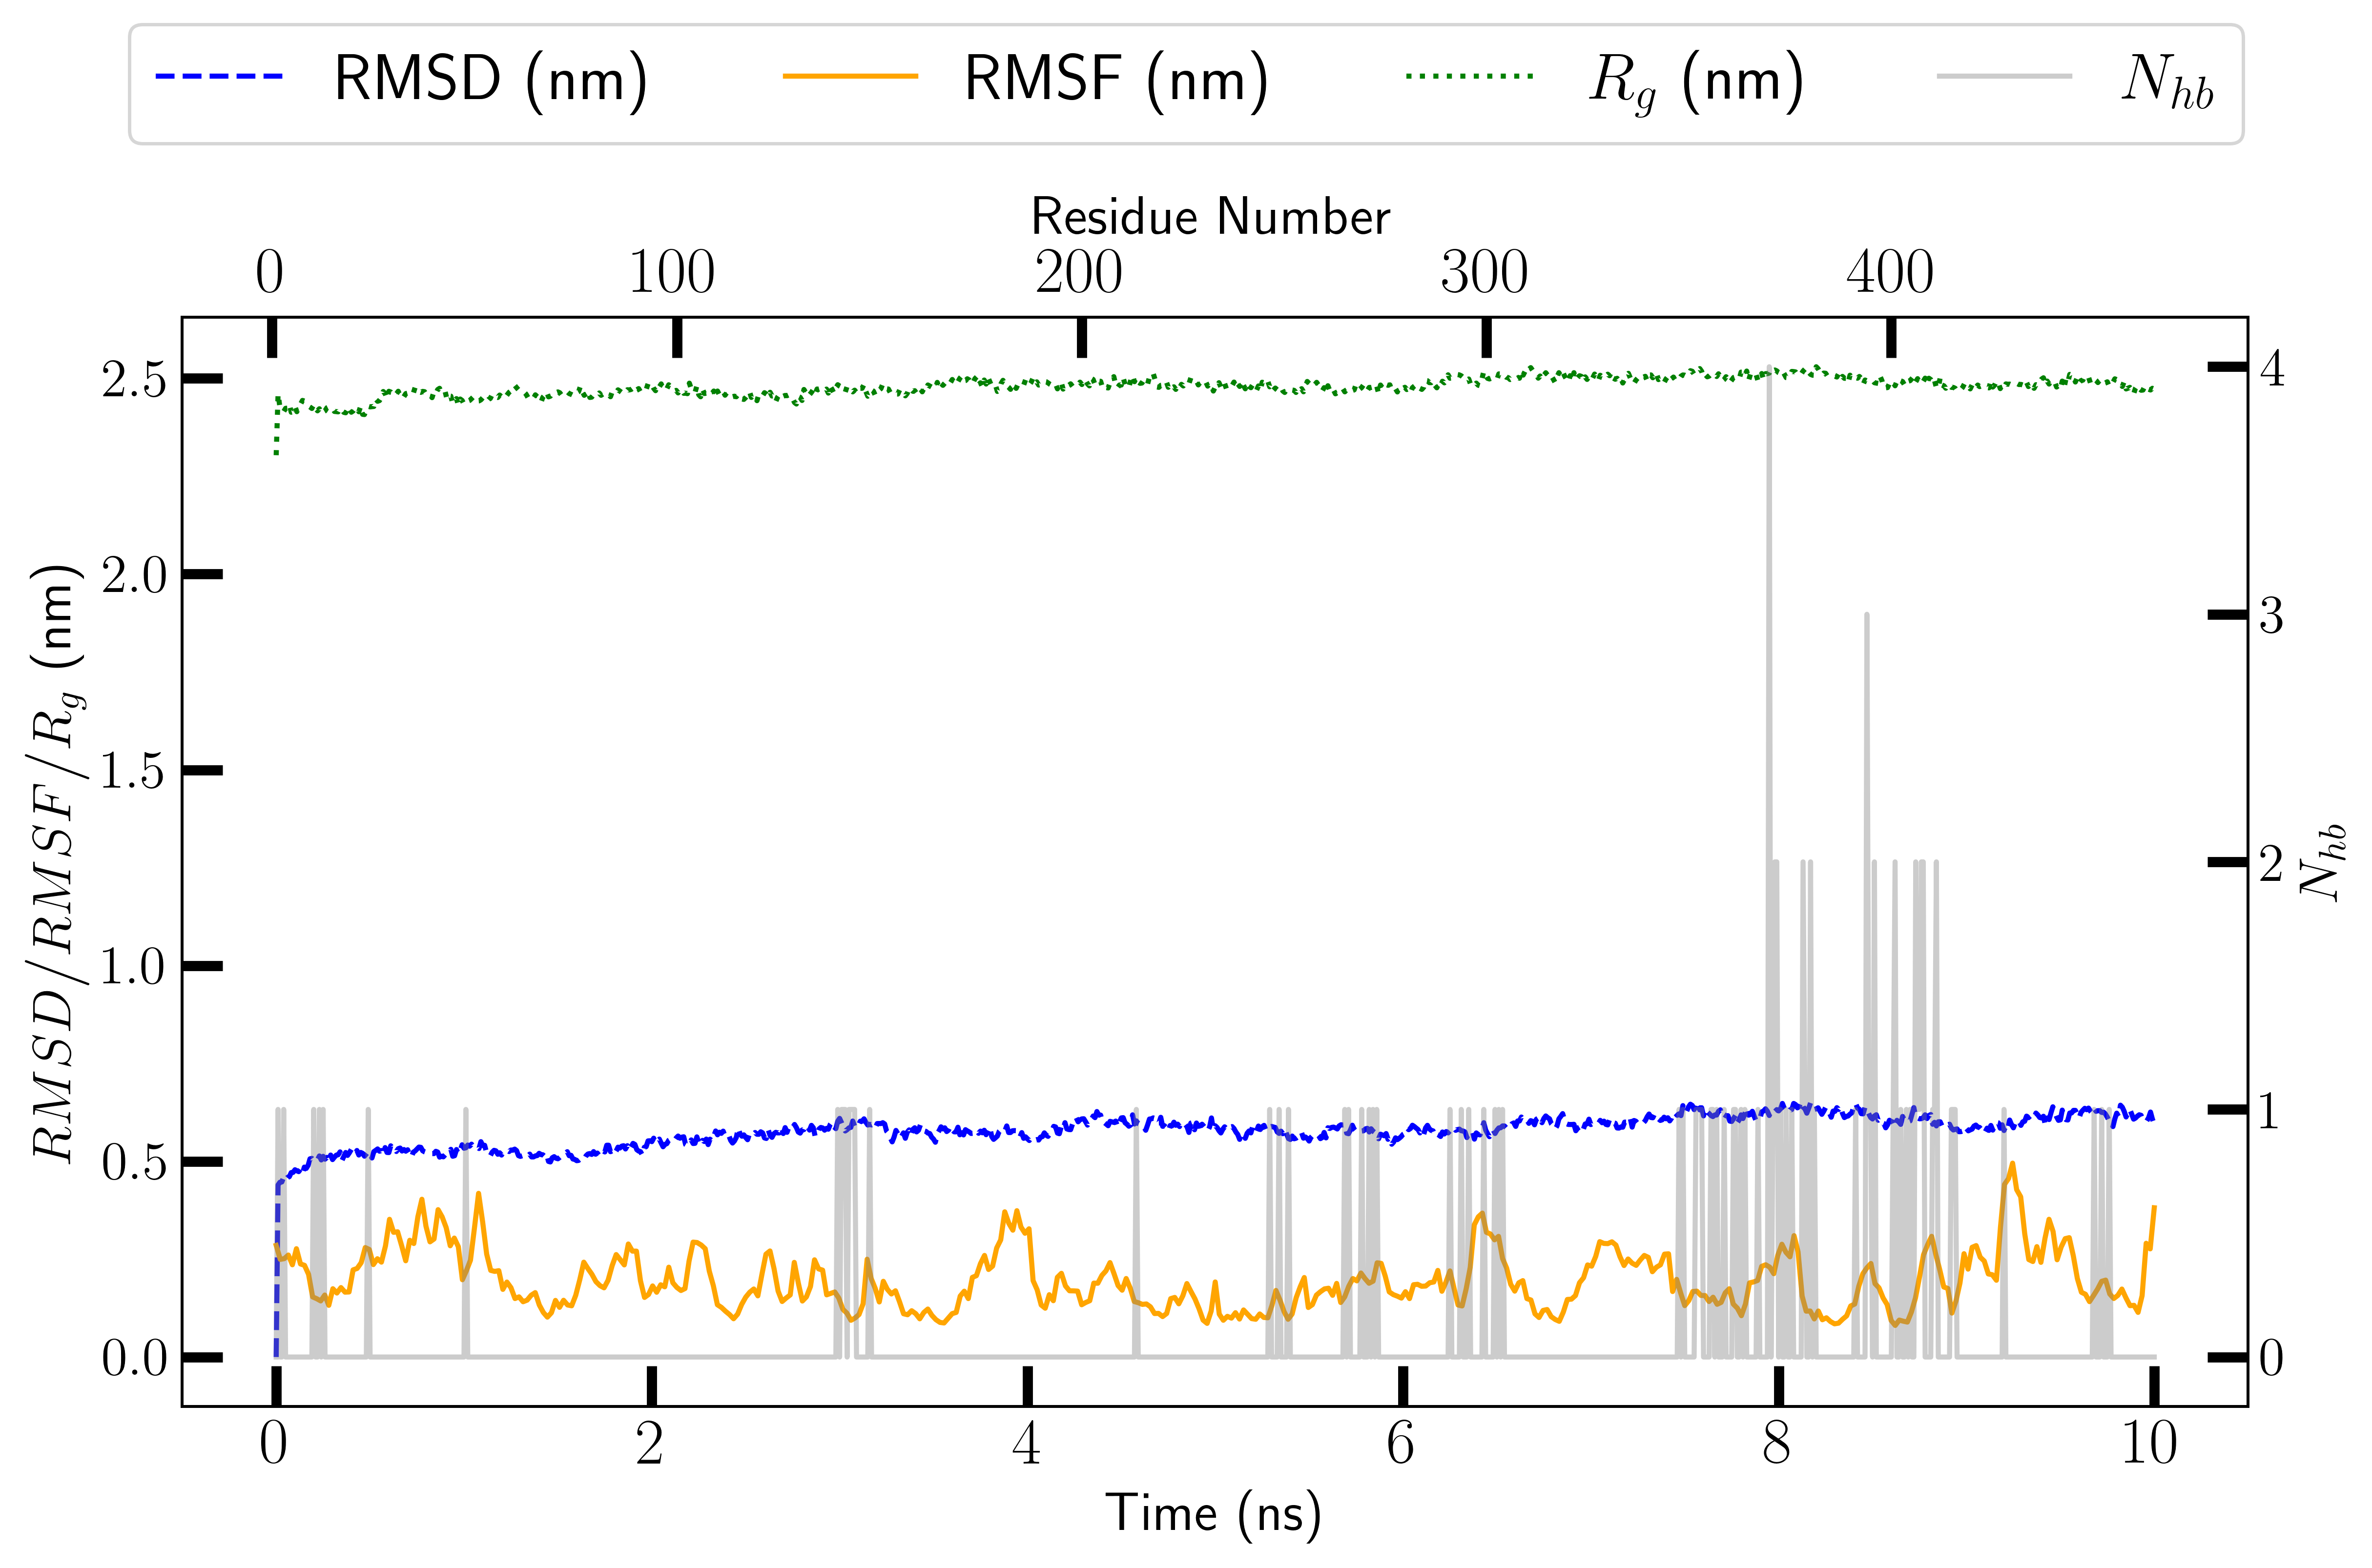

In [118]:
from matplotlib.ticker import MaxNLocator

fig, ax = plt.subplots(1, 1, figsize=(10, 6), sharey=True)


ax.set_xlabel('Time (ns)')
ax.set_ylabel(r"$RMSD\bigg/ RMSF \bigg/ R_g$ (nm)")
times = df['time']/1000 #Convert to nanoseconds
rmsd = df['rmsd']/10 # convert from Angstroms to nm
resids = np.array(df['resid'])
rmsf = np.array(df['rmsf'])
ax.plot(times, rmsd, color='blue', ls='dashed')
ax_top = ax.twiny()

ax_top.set_xlabel('Residue Number')
ymax = ax_top.get_ylim()[1]
ax_top.plot(resids, rmsf/10, color='orange', ls='solid')

times = np.array(df['time_rg'])/1000 #Convert to nanoseconds
rg = np.array(df['rg'])/10 # convert from Angstroms to nm
ax.plot(times, rg, color='green', ls=':')

ax_right = ax.twinx()
times = nhb_df.index.values/1000
ax_right.plot(times, nhb_df['nhb'], color='gray', alpha=0.4)
ax_right.set_ylim(-0.2, 4.2)
ax_right.yaxis.set_major_locator(MaxNLocator(integer=True))
ax_right.set_ylabel(r"$N_{hb}$")

line_rmsd = ax.lines[0]
line_rg = ax.lines[1]
line_rmsf = ax_top.lines[0]
line_nhb = ax_right.lines[0]
fig.legend([line_rmsd, line_rmsf, line_rg, line_nhb],
        ['RMSD (nm)', 'RMSF (nm)', r'$R_g$ (nm)', r'$N_{hb}$'],
        loc='upper center', bbox_to_anchor=(0.5, 1.1), ncol=4)

plt.savefig("rmsd_rmsf_rg_nhb_scaled8.svg", dpi=300, bbox_inches='tight')

## Distance metrics

In [73]:
# Calculate and plot the distance between the center of mass of the ligand and the center of mass of the protein
from MDAnalysis.analysis import distances
from tqdm.notebook import tqdm
import numpy as np
import pandas as pd

protein_com = complex.select_atoms('protein').center_of_mass()
ligand_com = complex.select_atoms('resname PDL').center_of_mass()
times = []
dists = []

for ts in tqdm(complex.trajectory):
    protein_com = complex.select_atoms('protein').center_of_mass()
    ligand_com = complex.select_atoms('resname PDL').center_of_mass()
    dist = distances.distance_array(protein_com, ligand_com)
    times.append(ts.time)
    dists.append(dist[0][0])
times = np.array(times)/1000 #Convert to nanoseconds
dists = np.array(dists)/10 # convert from Angstroms to nm

# Create a pandas dataframe
dist_df = pd.DataFrame({'time': times, 'distance': dists})


  0%|          | 0/1001 [00:00<?, ?it/s]

In [90]:
binding_residues = set(protein_residues)

# Calculate the distance between the ligand COM and each of the binding residues (COMs) over time
binding_dists = pd.DataFrame({'time': times})
for ts in tqdm(complex.trajectory):
    time = ts.time/1000 # Convert to nanoseconds
    ligand_com = ligand.center_of_mass()
    for res in binding_residues:
        res_sel = complex.select_atoms(f"resname {res[:-3]} and resid {res[-3:]}")
        res_com = res_sel.center_of_mass()
        dist = distances.distance_array(ligand_com, res_com)
    # Store the distance in the dataframe
        if res not in binding_dists.columns:
            binding_dists[res] = np.nan
        binding_dists.loc[binding_dists['time'] == time, res] = dist[0][0]/10 # convert from Angstroms to nm


  0%|          | 0/1001 [00:00<?, ?it/s]

In [91]:
binding_dists

,time,ILE151,ALA149,VAL163,ARG366,ALA229,HIS165,GLN365,VAL159,GLU369,TRP127,ASN150,PRO248,VAL162
0,0.00,1.672990,1.515475,1.115159,2.315779,1.058715,0.860825,2.135189,1.310207,2.383722,0.800163,1.297818,0.833889,0.909915
1,0.01,1.617803,1.175450,0.734623,1.390224,0.867497,0.924307,1.571142,0.958602,1.794138,1.248787,1.334401,0.982154,0.727831
2,0.02,1.442093,0.932082,0.737731,1.093140,1.017512,0.893788,1.445358,0.958885,1.560091,1.148306,1.054453,1.050310,0.708103
3,0.03,1.390336,0.858735,0.773062,1.188998,0.970571,0.949887,1.538590,1.062845,1.615789,1.182377,1.011334,1.115370,0.697176
4,0.04,1.473013,0.925811,0.816797,1.177947,0.999262,0.920459,1.511723,1.127470,1.570049,1.106409,1.089357,1.047326,0.783570
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
996,9.96,1.006412,0.624285,0.675522,0.844193,0.995780,1.141182,0.890065,0.820962,1.030806,1.617933,0.884382,0.862565,0.763201
997,9.97,0.964292,0.591847,0.685922,0.835131,0.983752,1.171602,0.937352,0.836517,1.038583,1.677329,0.842885,0.837155,0.780635
998,9.98,0.934672,0.610104,0.660867,0.839388,0.929679,1.156253,1.001129,0.769646,1.055753,1.712826,0.838951,0.796950,0.769443
999,9.99,0.954060,0.620553,0.699680,0.825020,1.010393,1.203442,0.886229,0.774873,1.071029,1.681820,0.870608,0.828154,0.785830


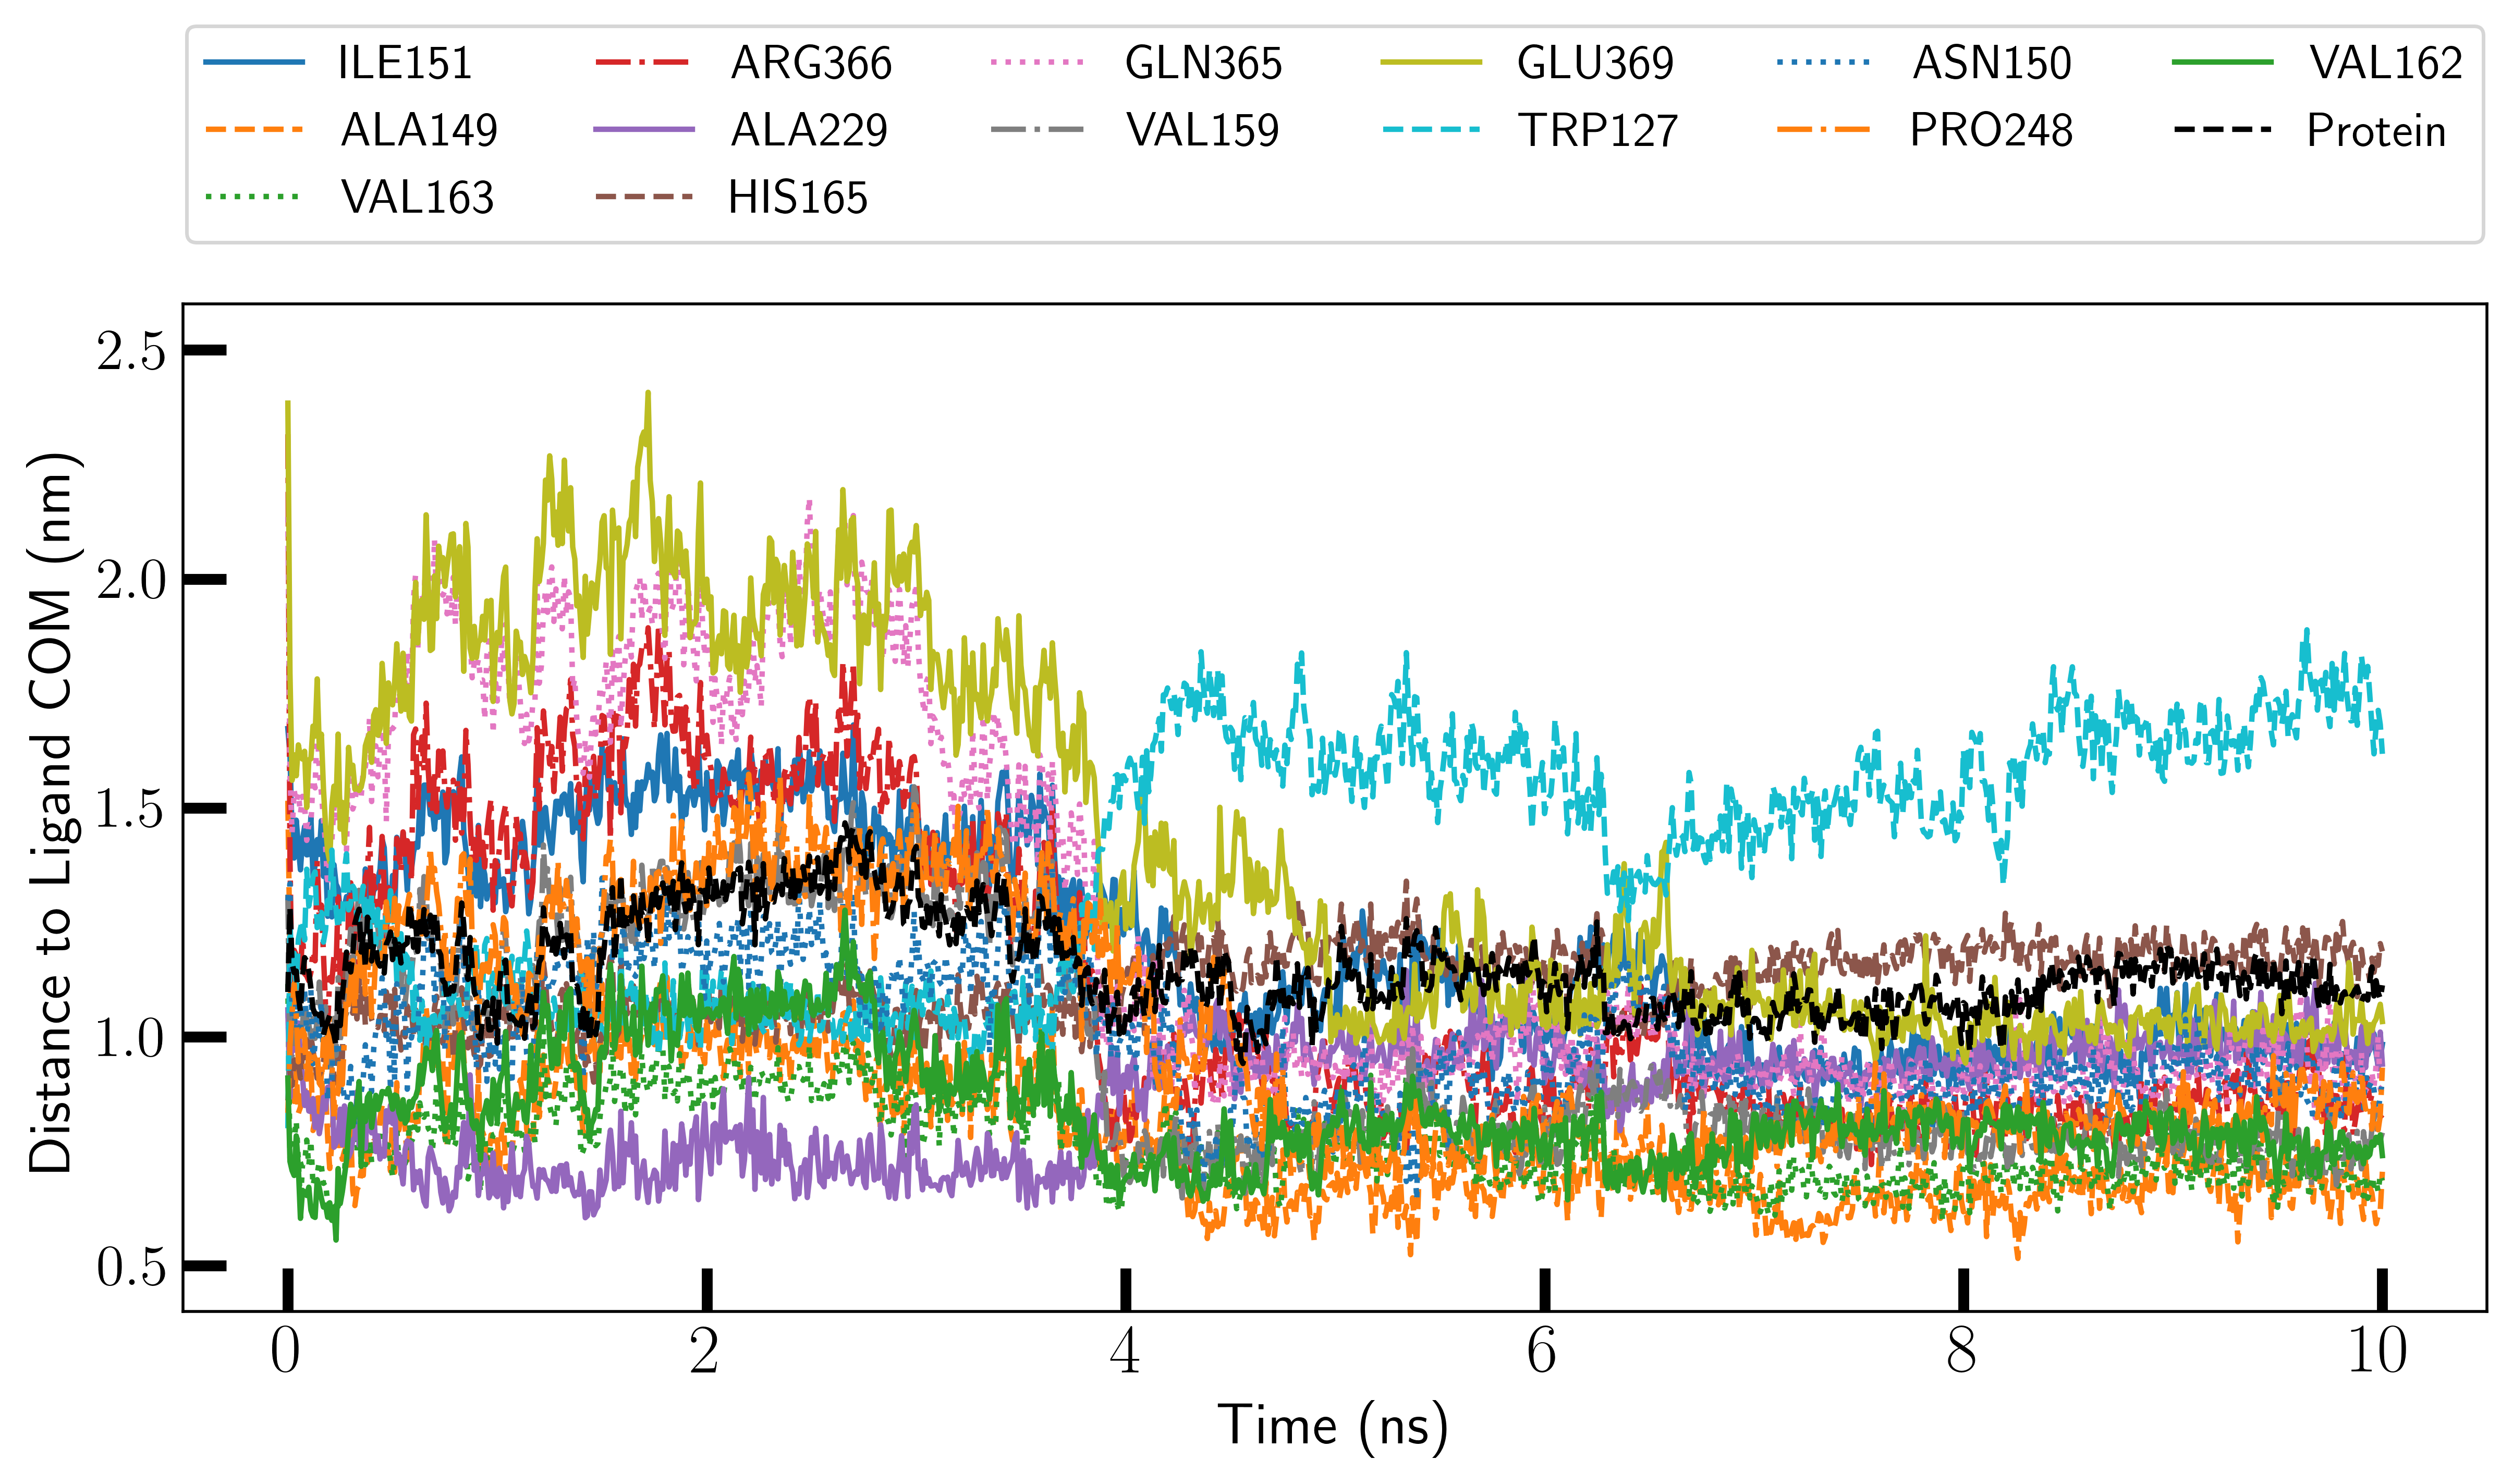

In [119]:
# Now, plot them
from itertools import cycle
plt.figure(figsize=(10, 6))

line_styles = cycle(['-', '--', ':', '-.'])

for res in binding_residues:
    plt.plot(binding_dists['time'], binding_dists[res], label=res, ls=next(line_styles))
plt.xlabel('Time (ns)')
plt.ylabel('Distance to Ligand COM (nm)')
plt.ylim(0.4, 2.6)
#Add the plot for the ligand-protein COM distance
plt.plot(dist_df['time'], dist_df['distance'], label='Protein', color='black', ls='--')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.3), ncol=6, fontsize='small')
plt.savefig("binding_distances_scaled8.svg", dpi=300, bbox_inches='tight')
plt.show()

## Hydrogen Bond Occupancy Statistics

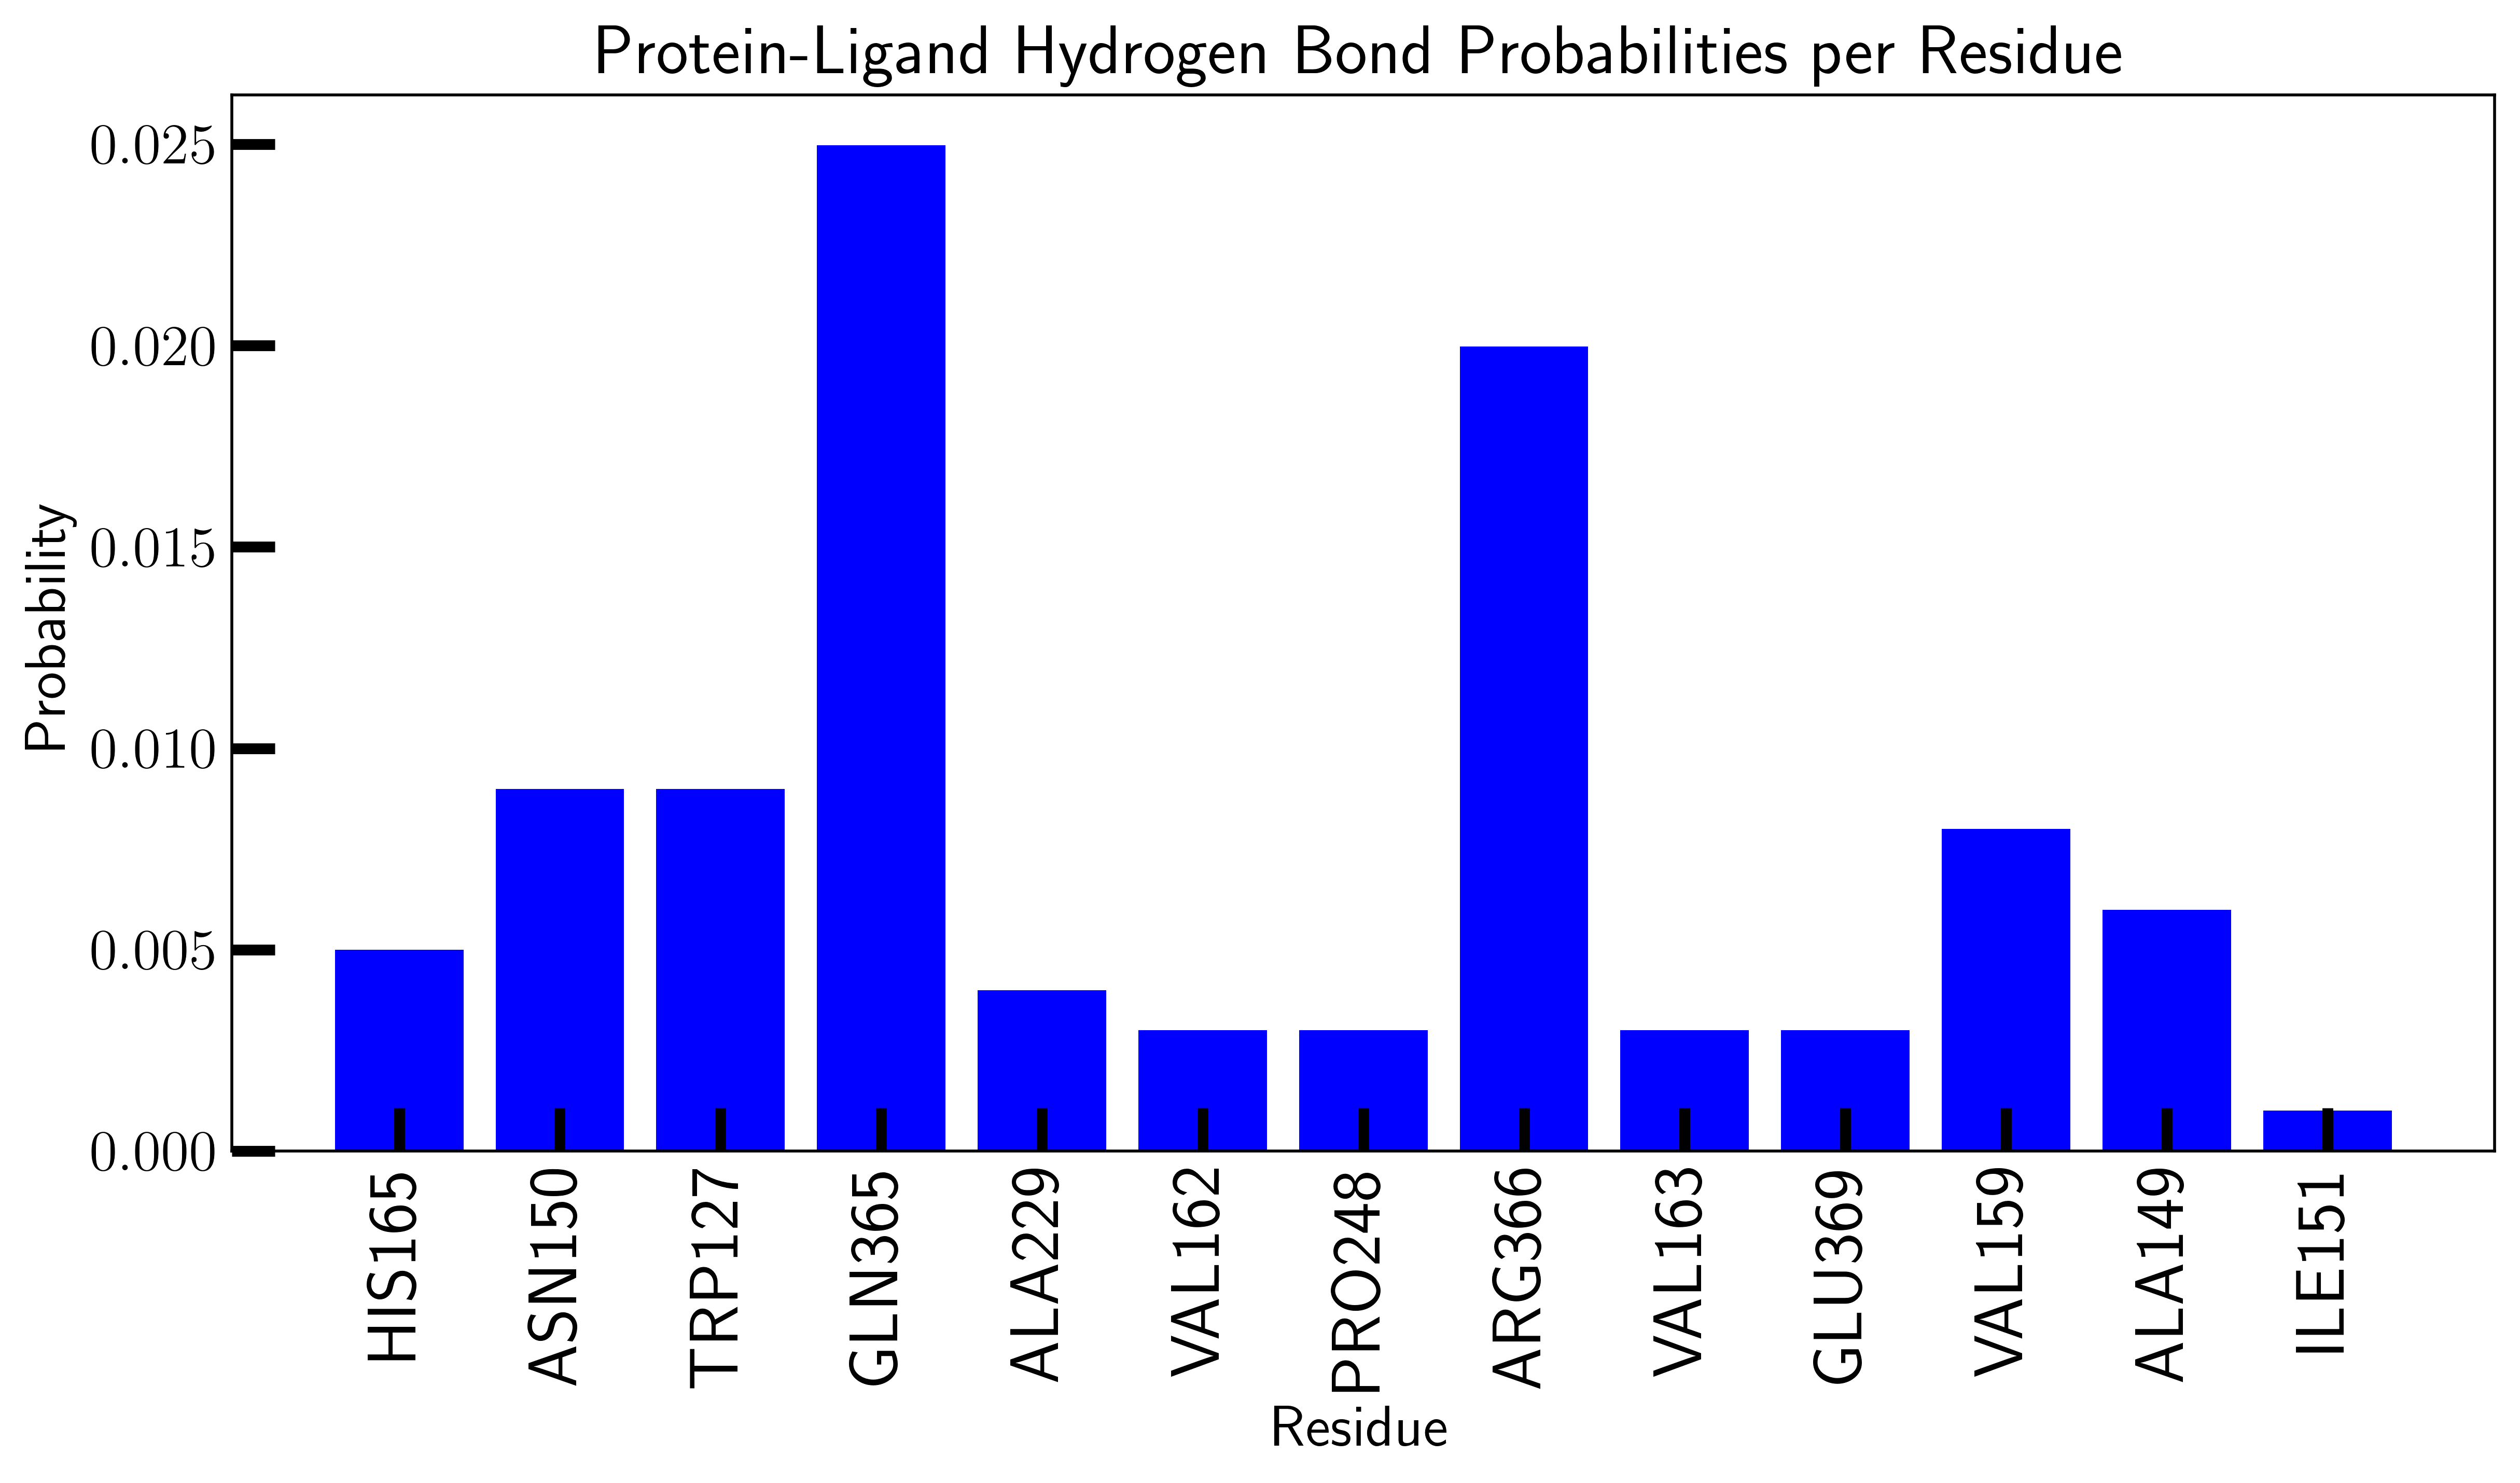

In [135]:
# Estimate the hydrogen bond probabilities (total number of frames with a given number of H-bonds divided by total number of frames) per participating residue and plot in a histogram. The x-axis contains the participating residues and the y-axis contains the probabilities. The title of the plot is "Hydrogen Bond Probabilities per Residue". The bars are colored in blue.
from collections import Counter
import matplotlib.pyplot as plt
residue_counts = Counter(protein_residues)
total_frames = len(complex.trajectory)
residue_probabilities = {res: count/total_frames for res, count in residue_counts.items()}
plt.figure(figsize=(10, 6))
plt.bar(residue_probabilities.keys(), residue_probabilities.values(), color='blue')
plt.xlabel('Residue')
plt.ylabel('Probability')
plt.title('Protein-Ligand Hydrogen Bond Probabilities per Residue')
plt.xticks(rotation=90)
plt.savefig("hbond_probabilities_scaled8.svg", dpi=300, bbox_inches='tight')
plt.show()